In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df_raw = pd.read_csv('hulu_titles.csv')

In [3]:
df = df_raw.copy()

In [4]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Ricky Velez: Here's Everything,NaN,NaN,NaN,"October 24, 2021",2021,TV-MA,NaN,"Comedy, Stand Up",​Comedian Ricky Velez bares it all with his ho...
1,s2,Movie,Silent Night,NaN,NaN,NaN,"October 23, 2021",2020,NaN,94 min,"Crime, Drama, Thriller","Mark, a low end South London hitman recently r..."
2,s3,Movie,The Marksman,NaN,NaN,NaN,"October 23, 2021",2021,PG-13,108 min,"Action, Thriller",A hardened Arizona rancher tries to protect an...
3,s4,Movie,Gaia,NaN,NaN,NaN,"October 22, 2021",2021,R,97 min,Horror,A forest ranger and two survivalists with a cu...
4,s5,Movie,Settlers,NaN,NaN,NaN,"October 22, 2021",2021,NaN,104 min,"Science Fiction, Thriller",Mankind's earliest settlers on the Martian fro...


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3073 entries, 0 to 3072
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   show_id       3073 non-null   object 
 1   type          3073 non-null   object 
 2   title         3073 non-null   object 
 3   director      3 non-null      object 
 4   cast          0 non-null      float64
 5   country       1620 non-null   object 
 6   date_added    3045 non-null   object 
 7   release_year  3073 non-null   int64  
 8   rating        2553 non-null   object 
 9   duration      2594 non-null   object 
 10  listed_in     3073 non-null   object 
 11  description   3069 non-null   object 
dtypes: float64(1), int64(1), object(10)
memory usage: 288.2+ KB


In [6]:
df.shape

(3073, 12)

i can see that the director and cast columns as useless as they only have null values.......so i will drop them

In [7]:
df = df.drop(columns = ['director', 'cast'])




checking for duplicates and null values

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.isna().sum()

show_id            0
type               0
title              0
country         1453
date_added        28
release_year       0
rating           520
duration         479
listed_in          0
description        4
dtype: int64

In [10]:
df.isna().sum().sum()

np.int64(2484)

In [11]:
df.isna().mean()*100

show_id          0.000000
type             0.000000
title            0.000000
country         47.282786
date_added       0.911162
release_year     0.000000
rating          16.921575
duration        15.587374
listed_in        0.000000
description      0.130166
dtype: float64

In [12]:
df.nunique()

show_id         3073
type               2
title           3073
country          150
date_added      1115
release_year      72
rating            88
duration         135
listed_in        442
description     3057
dtype: int64

# Questions : 

### What’s the split of Movies vs TV Shows?
### Which countries contribute most content?
### How has content changed over release_year and date_added?
### What are the top genres (listed_in)?
### How do ratings differ by type?

## 1) split between movies and tv shows :

i'll just compare the total number of movies and tv shows using a bar graph and a pie chart

#### Method 1 (Using matplotlib - we need arrays/lists/tuples here) :

In [13]:
series1 = df['type'].value_counts()

In [14]:
df['type'].value_counts().values

array([1589, 1484])

<BarContainer object of 2 artists>

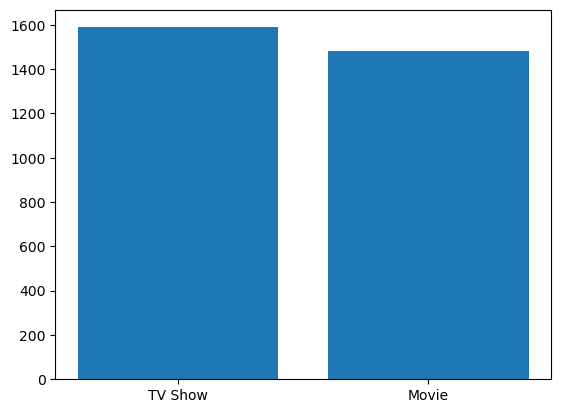

In [15]:
plt.bar(x=series1.index, height=series1.values)

#### Method 2 (using seaborn - we need dataframe and its columns) :

<Axes: xlabel='type', ylabel='count'>

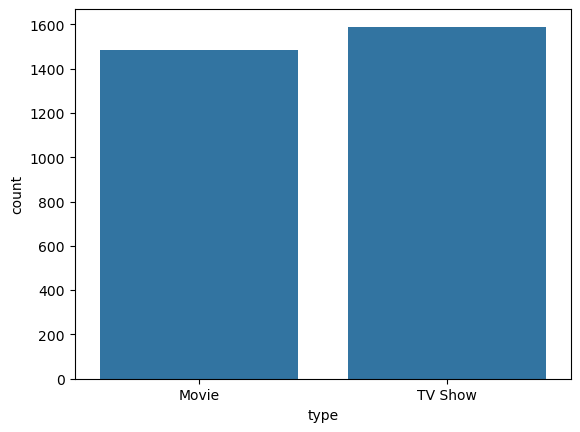

In [16]:
sns.countplot(data = df, x = 'type')

#### Method 3 (using seaborn barplot):

In [17]:
ser2 = df['type'].value_counts().reset_index()
ser2

,type,count
0,TV Show,1589
1,Movie,1484


<Axes: xlabel='type', ylabel='count'>

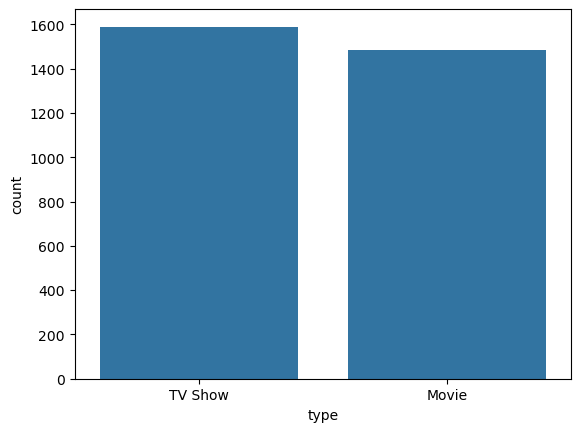

In [18]:
sns.barplot(data=ser2, x='type', y='count')

SO WE CAN SEE THAT MORE TV SHOWS ARE AVAILABLE ON HULU AS COMPARED TO MOVIES BUT THE MARGIN BETWEEN THE TWO TYPES IS LOW

## 2) Which countries contribute most content?

In [19]:
df.groupby('country').size()

country
Afghanistan, United States                           1
Australia                                           20
Australia, United Arab Emirates                      1
Australia, United Kingdom                            1
Australia, United States                             1
                                                    ..
United States, United Kingdom, Australia, Canada     1
United States, United Kingdom, France                1
United States, United Kingdom, Germany, Canada       1
United States, United Kingdom, Italy                 1
Venezuela                                            1
Length: 150, dtype: int64

we can see that the country column contains multiple values in each row. But we want one value per row. Therefore we use split + explode :

In [20]:
df_country = df.copy()
df_country['country']=df_country['country'].astype('string')
df_country['country'] = df_country['country'].str.split(r',\s*')
df_country = df_country.explode('country')

In [21]:
df_country['country'].sample(5)

2931    United States
846              <NA>
423              <NA>
2594    United States
772              <NA>
Name: country, dtype: object

In [22]:
counts = df_country.groupby('country').size().sort_values(ascending=False).head(10).reset_index(name= 'count')
counts

,country,count
0,United States,1097
1,Japan,281
2,United Kingdom,200
3,Canada,88
4,Germany,41
5,France,40
6,Australia,36
7,Sweden,20
8,Denmark,17
9,South Korea,15


<Axes: xlabel='count', ylabel='country'>

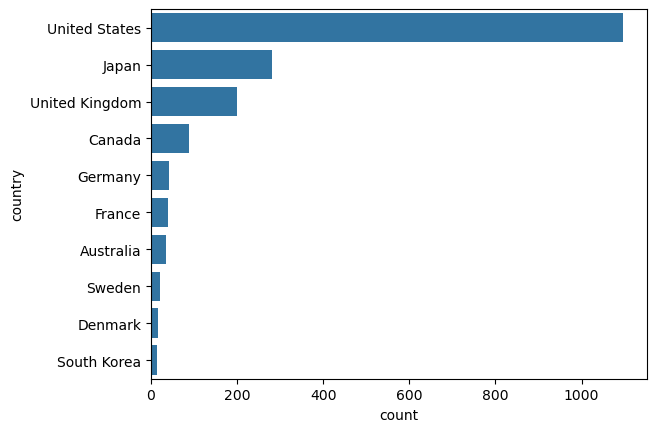

In [23]:
sns.barplot(data=counts, x='count', y='country')

This tells us the overall distribution/contribution of content (movies + tv shows) by different countries

Now let us see the type-wise distribution

In [24]:
df_type = df_country.groupby(['country', 'type']).size().reset_index(name='count')
df_type

,country,type,count
0,Afghanistan,Movie,1
1,Argentina,Movie,2
2,Australia,Movie,25
3,Australia,TV Show,11
4,Austria,Movie,2
...,...,...,...
70,United Kingdom,TV Show,86
71,United States,Movie,486
72,United States,TV Show,611
73,Uruguay,Movie,1


In [25]:
top_10_countries = df_type.groupby('country')['count'].sum().sort_values(ascending = False).head(10).index

In [26]:
top_10_countries

Index(['United States', 'Japan', 'United Kingdom', 'Canada', 'Germany',
       'France', 'Australia', 'Sweden', 'Denmark', 'South Korea'],
      dtype='object', name='country')

In [27]:
df_type = df_type[df_type['country'].isin(top_10_countries)]

In [28]:
df_type

,country,type,count
2,Australia,Movie,25
3,Australia,TV Show,11
8,Canada,Movie,54
9,Canada,TV Show,34
17,Denmark,Movie,16
18,Denmark,TV Show,1
20,France,Movie,35
21,France,TV Show,5
23,Germany,Movie,35
24,Germany,TV Show,6


<Axes: xlabel='count', ylabel='country'>

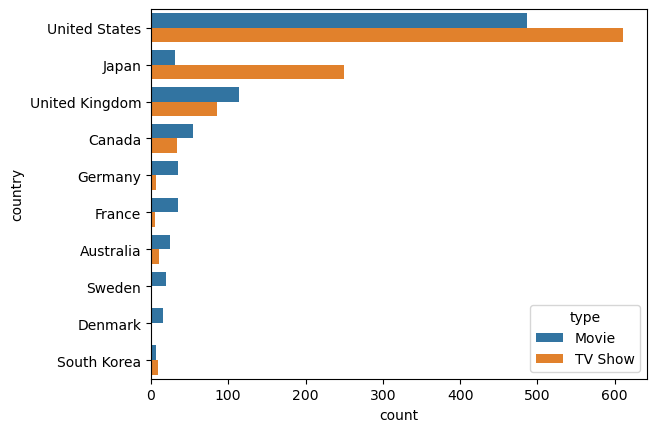

In [29]:
sns.barplot(data=df_type, x='count', y='country', hue='type', order=top_10_countries)

We now get the distribution of movies and tv shows for the top 10 countries (ranked based the total number of movies and tv shows combined)

## 3) How has content changed over release_year and date_added?¶

In [30]:
df.sample(5)

,show_id,type,title,country,date_added,release_year,rating,duration,listed_in,description
1766,s1767,TV Show,Yu-Gi-Oh! ARC-V,NaN,"March 15, 2020",2016,TV-Y7,3 Seasons,"Action, Anime, International",Yuya Sakaki’s dream is to follow in his father...
137,s138,Movie,The Extreme Adventures of Super Dave,NaN,"October 1, 2021",2000,PG,91 min,Comedy,A klutzy but legendary stuntman named Super Da...
917,s918,Movie,Triggered,NaN,"March 6, 2021",2020,NaN,94 min,Thriller,"After a night of partying, nine friends wake u..."
2595,s2596,TV Show,Sonic Boom,"United States, France","November 19, 2017",2014,TV-Y7,2 Seasons,"Adventure, Cartoons, Comedy",It’s a Sonic you haven’t seen before – an ense...
953,s954,TV Show,North Korea: Inside the Mind of a Dictator,NaN,"February 16, 2021",2021,TV-14,1 Season,Documentaries,Exclusive interviews and intimate archival inf...


In [31]:
df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')

In [32]:
df_genre = df.copy()
df_genre['listed_in']=df_genre['listed_in'].astype('string').str.split(r',\s*')
df_genre = df_genre.explode('listed_in')

In [33]:
count = df_genre.groupby(['release_year', 'listed_in']).size().reset_index(name='counts')

<Axes: xlabel='release_year', ylabel='counts'>

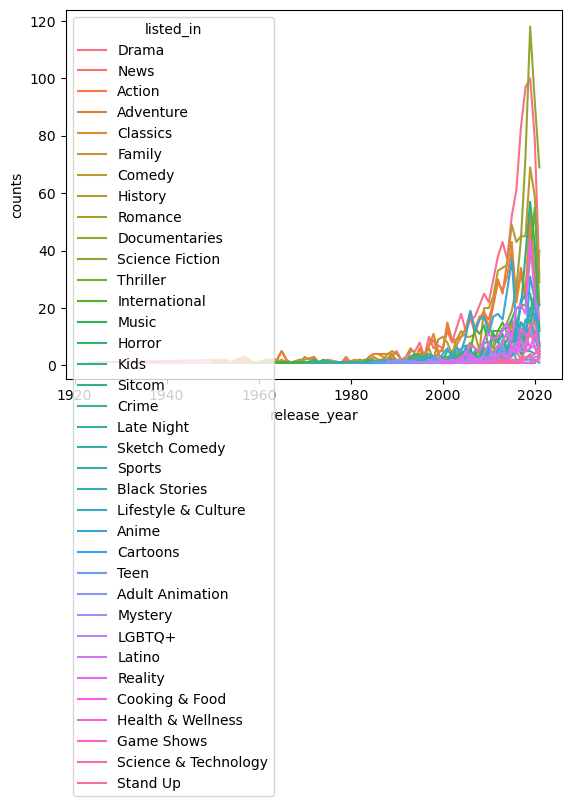

In [34]:
sns.lineplot(data = count, x = 'release_year', y='counts', hue='listed_in')

we can see that this is very messy. So a better way would be to select the top 10 or 15 genres plot the line plot only for those genres

In [35]:
top_n = count.groupby('listed_in')['counts'].sum().sort_values(ascending=False).head(5).index

In [36]:
count = count[count['listed_in'].isin(top_n)]

# we are just filtering counts so that we are left with only the top n genres (ranked based on the total amount of content from that genre over the years)

<Axes: xlabel='release_year', ylabel='counts'>

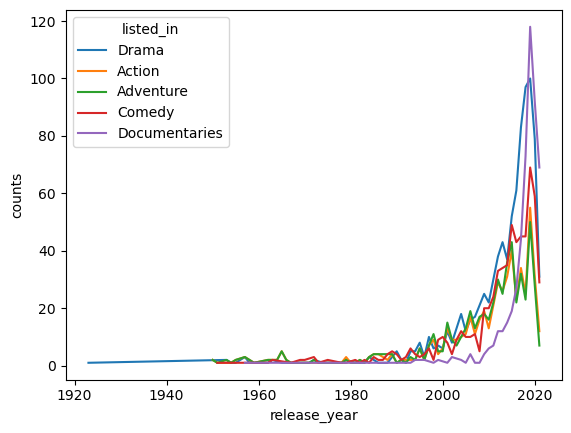

In [37]:
sns.lineplot(data=count, x='release_year', y='counts', hue='listed_in')

we can see that more documentries were released in the recent years, followed by dramas, comedies, actions and adventures respectively

i will now look at the variation of content wrt date_added

In [38]:
# i already coverted the date_added column from object to datetime64, so no need to do that again but make sure to do it!!
df['added_year'] = df['date_added'].dt.year
df['added_month'] = df['date_added'].dt.to_period('M').astype(str) # 2021-10-24 → 2021-10
added = df.groupby('added_month').size().reset_index(name='count')

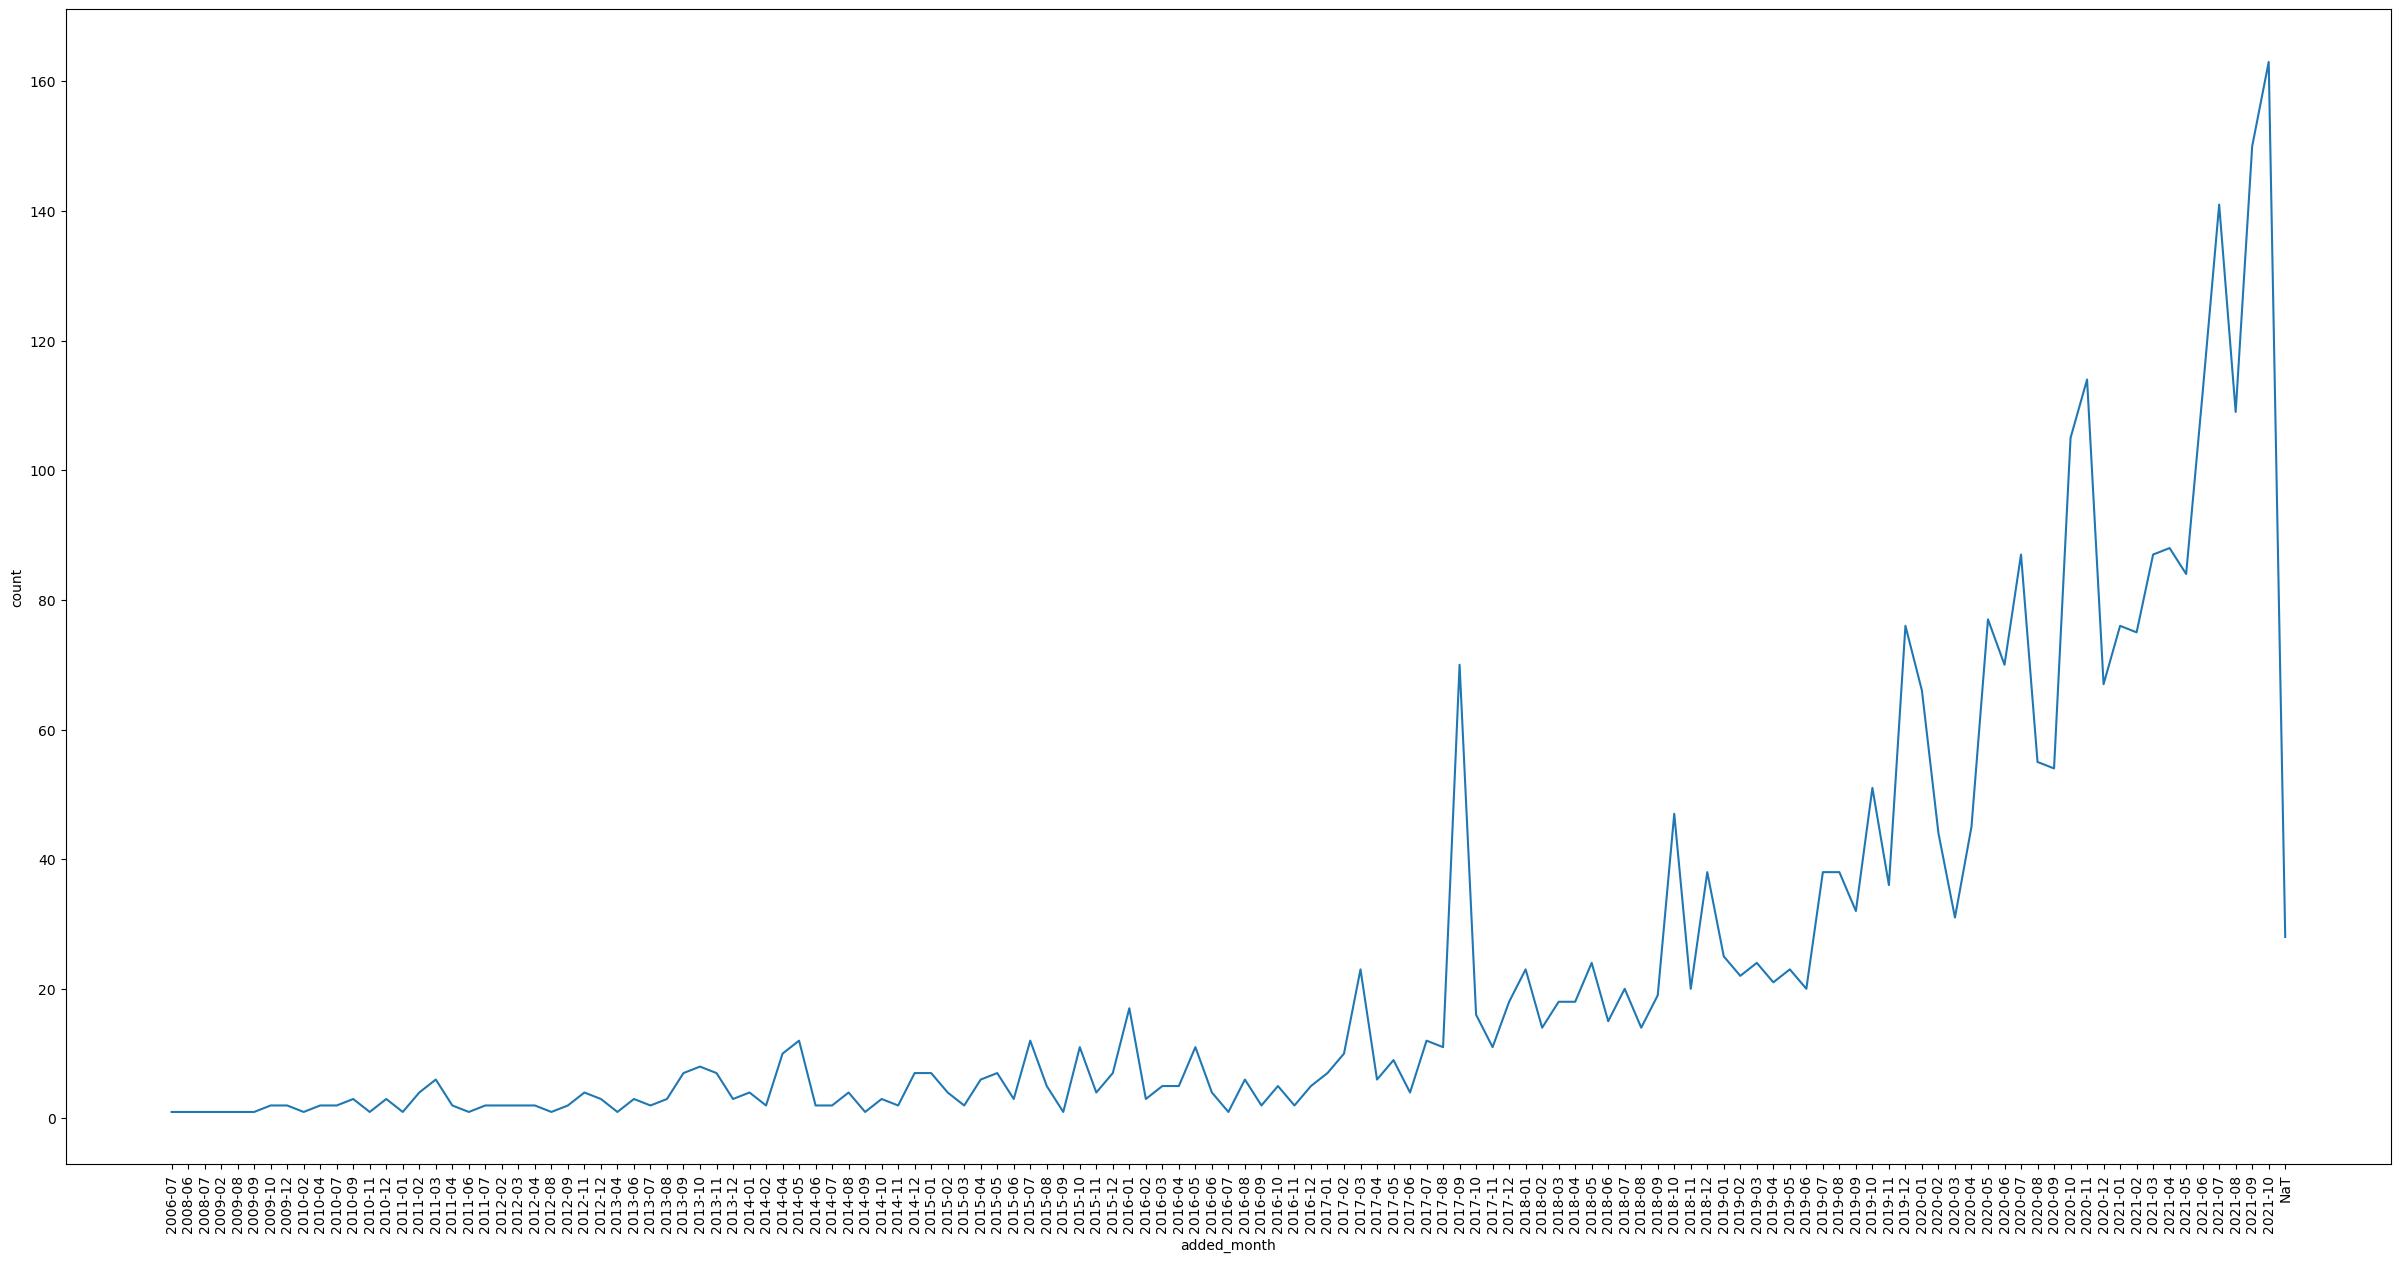

In [39]:
plt.figure(figsize=(30, 15))
sns.lineplot(data=added, x='added_month', y='count')
plt.xticks(rotation=90)
plt.show()

In [40]:
df_genre = df.copy()
df_genre['listed_in']=df_genre['listed_in'].astype('string').str.split(r',\s*')
df_genre = df_genre.explode('listed_in')
df_genre['listed_in'].sample(10)
count = df_genre.groupby(['release_year', 'listed_in']).size().reset_index(name='counts')
top_n = count.groupby('listed_in')['counts'].sum().sort_values(ascending=False).head(5).index

<Axes: xlabel='added_year', ylabel='count'>

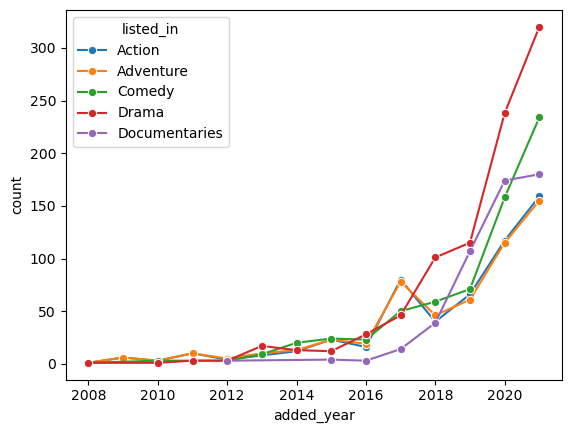

In [41]:
added_genre = df_genre.groupby(['added_year','listed_in']).size().reset_index(name='count')
added_genre = added_genre[added_genre['listed_in'].isin(top_n)]
sns.lineplot(data=added_genre, x='added_year', y='count', hue='listed_in', marker='o')

this plot tells us that Hulu added more and more Dramas 

Let us now see how old the content was when Hulu added it :

In [42]:
df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')

df_age = df.dropna(subset=['date_added']).copy()
df_age['age_when_added'] = df_age['date_added'].dt.year - df_age['release_year']
df_age = df_age[df_age['age_when_added'] >= 0]

<Axes: xlabel='age_when_added', ylabel='Count'>

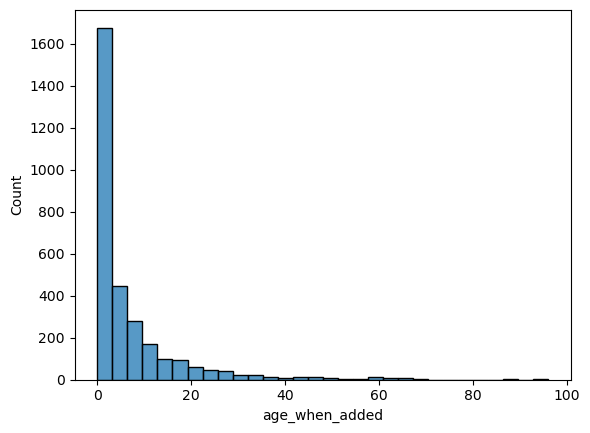

In [43]:
sns.histplot(df_age['age_when_added'].dropna(), bins=30)

Most titles are added within a few years of release

#### Titles added over time (monthly trend) :

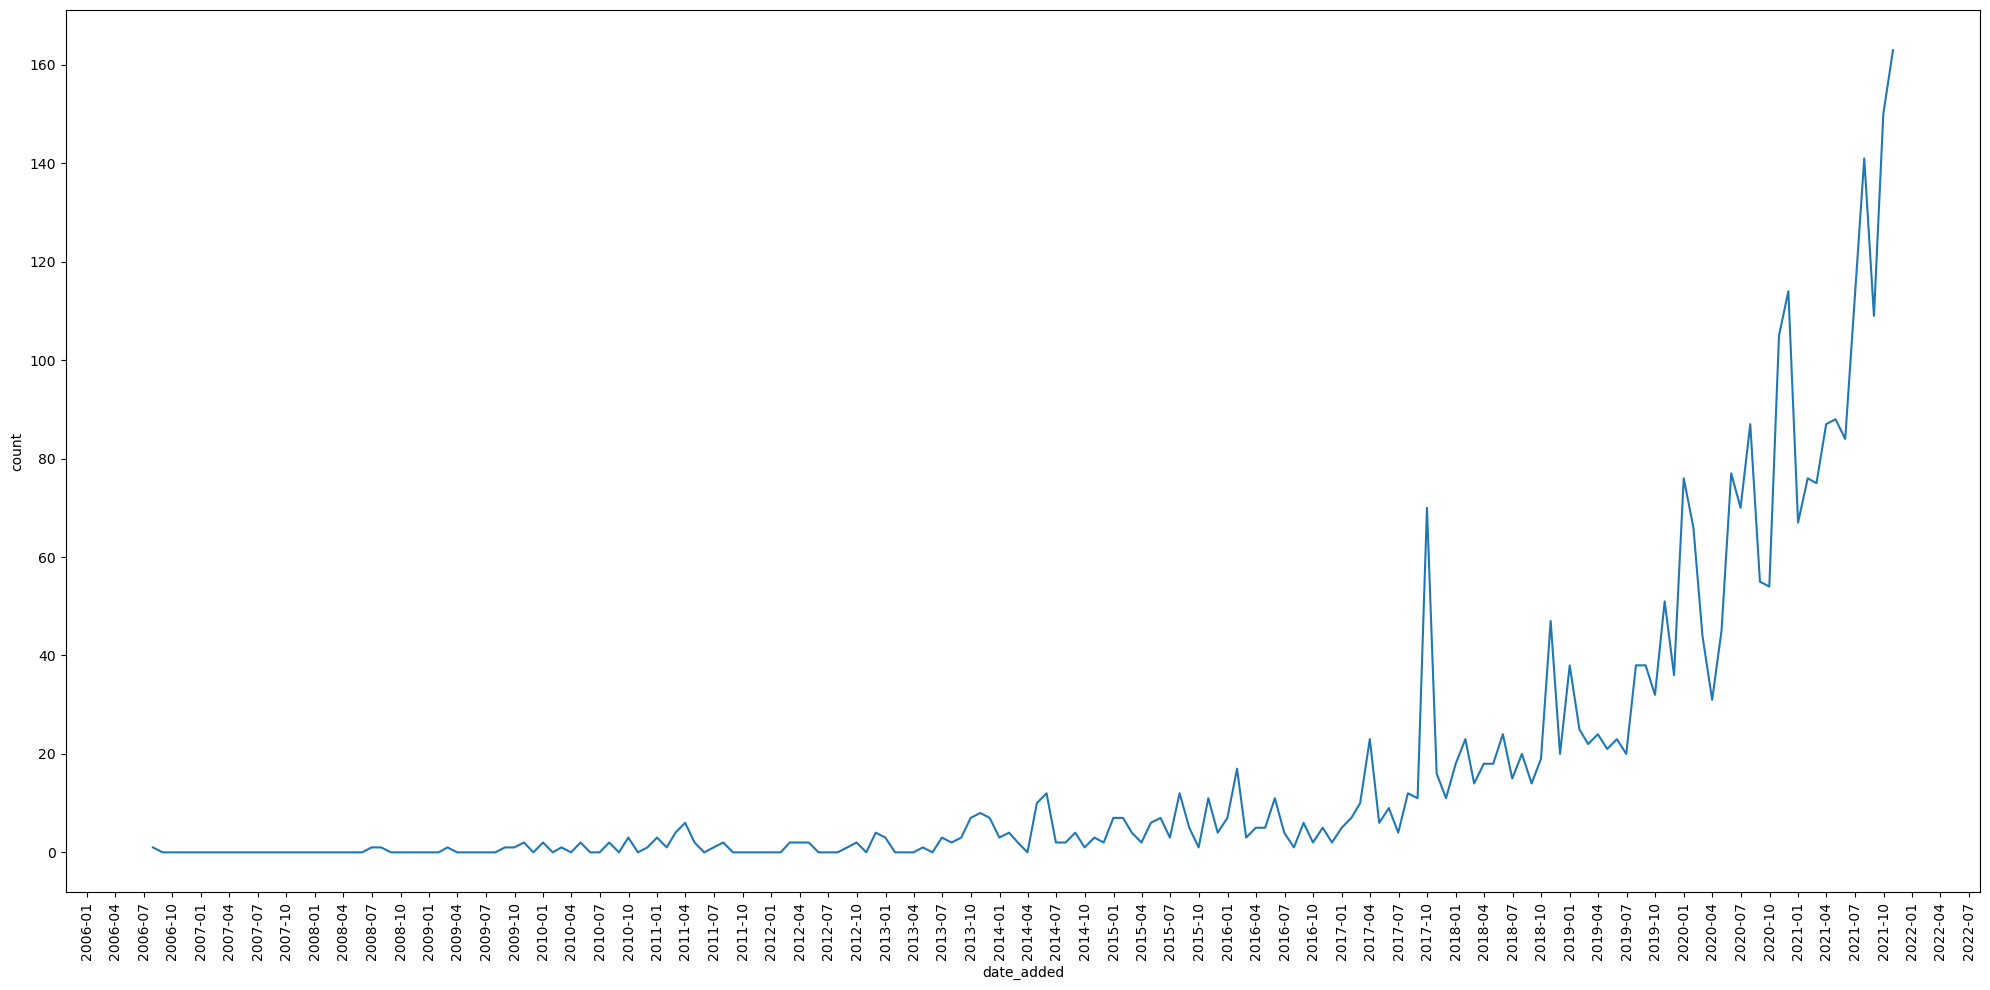

In [44]:
df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')
d = df.dropna(subset=['date_added']).set_index('date_added') # dropping rows with no dates and converting the updated date_added column to index

monthly = d.resample('ME').size().reset_index(name='count') # resample('M') just makes groups the data as per Months
plt.figure(figsize=(20, 10))
ax = sns.lineplot(data=monthly, x='date_added', y='count')

# the graph will show years on x axis but i want months at the interval of 3 months, so i must do the below written things :
import matplotlib.dates as mdates
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))      # every 3 months
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.xticks(rotation=90)
plt.tight_layout()

#### Added over time by type (Movie vs TV Show) :

<Axes: xlabel='date_added', ylabel='count'>

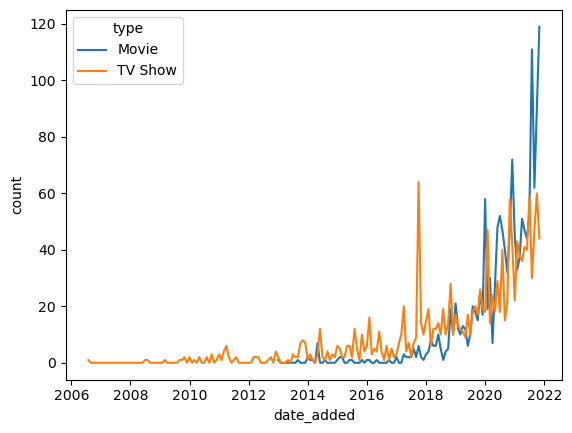

In [45]:
monthly_type = (d.groupby('type')
                  .resample('ME')
                  .size()
                  .reset_index(name='count'))

sns.lineplot(data=monthly_type, x='date_added', y='count', hue='type')

#### Seasonality (which months Hulu adds more) :

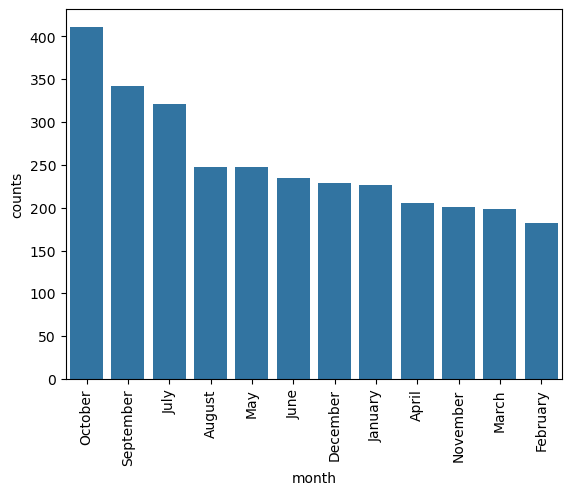

In [46]:
df_m = df.dropna(subset=['date_added']).copy()
df_m['month'] = df_m['date_added'].dt.month_name()
temp = df_m['month'].value_counts().reset_index(name='counts')

sns.barplot(data=temp, x = 'month', y = 'counts')
plt.xticks(rotation=90)
plt.show()

## 4) What are the top genres (listed_in)?¶

In [47]:
count = df_genre.groupby(['release_year', 'listed_in']).size().reset_index(name='counts')
top_each_year = count.loc[count.groupby('release_year')['counts'].idxmax()].sort_values('release_year')

In [48]:
top_each_year

,release_year,listed_in,counts
0,1923,Drama,1
1,1933,News,1
2,1950,Action,2
6,1951,Action,1
12,1953,Adventure,2
...,...,...,...
816,2017,Drama,83
847,2018,Drama,97
876,2019,Documentaries,118
909,2020,Documentaries,92


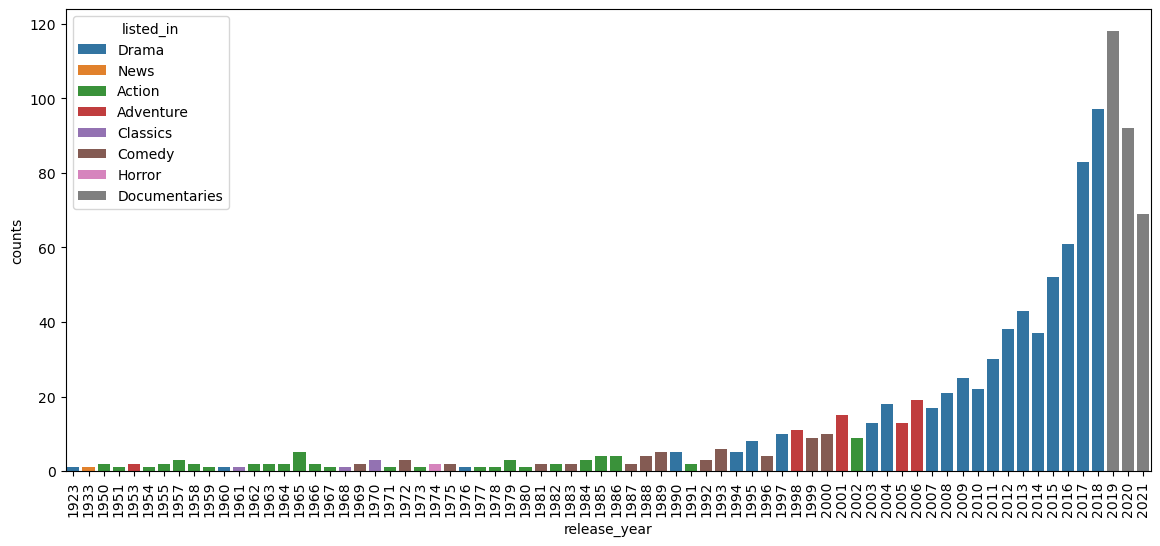

In [49]:
plt.figure(figsize=(14,6))
sns.barplot(data=top_each_year, x='release_year', y='counts', hue='listed_in')
plt.xticks(rotation=90)
plt.show()

so we can now see which genre was the most popular in each release year

we can also observe that the number of movies of top genres released each year has increased over the years

## 5) How do ratings differ by genre (listed_in)?

In [50]:
df_genre.sample(10)

,show_id,type,title,country,date_added,release_year,rating,duration,listed_in,description,added_year,added_month
1908,s1909,Movie,Day of the Falcon,NaN,2019-12-31,2013,R,130 min,Action,"To find peace after a long and bloody war, two...",2019.0,2019-12
2086,s2087,Movie,Hotel Mumbai,"Australia, United States, United Kingdom, Indi...",2019-09-09,2018,R,123 min,Thriller,A gripping true story that recounts the siege ...,2019.0,2019-09
2799,s2800,TV Show,Atlantis,United Kingdom,2016-05-08,2013,TV-PG,2 Seasons,Adventure,Ancient Greek myths and legends are brought to...,2016.0,2016-05
1442,s1443,Movie,Before Midnight,NaN,2020-08-14,2013,R,109 min,Drama,"On an idyllic Greek vacation, longtime couple ...",2020.0,2020-08
672,s673,Movie,Walking Tall,NaN,2021-06-01,1973,R,125 min,Adventure,Based on true events in the life of Tennessee ...,2021.0,2021-06
958,s959,TV Show,Bride and Prejudice: Forbidden Love,United States,2021-02-15,2020,TV-14,1 Season,Reality,"Bride & Prejudice"" tackles race, religion, and...",2021.0,2021-02
2003,s2004,TV Show,After School Dice Club,NaN,2019-11-01,2019,TV-PG,1 Season,Drama,"During a beautiful day in Kyoto, Aya and Miki ...",2019.0,2019-11
1645,s1646,Movie,I Still Believe,United States,2020-05-26,2020,PG,116 min,Music,From the makers of I CAN ONLY IMAGINE comes th...,2020.0,2020-05
1085,s1086,Movie,Bayou Caviar,United States,2020-12-31,2018,TV-MA,111 min,Black Stories,Oscar® winner Cuba Gooding Jr.’s directorial d...,2020.0,2020-12
2156,s2157,Movie,Somm 3,United States,2019-07-18,2018,79 min,NaN,Documentaries,Three of the greatest legends in wine meet to ...,2019.0,2019-07


we can see that some entries in the rating column contain the duration (like 121 min and 1 season). So we have to deal with these rows first.

In [51]:
df['rating'] = df['rating'].astype('string')
df['duration'] = df['duration'].astype('string')

mask = df_genre['rating'].str.match(r'^\s*\d+\s*(min|Season|Seasons)\s*$', na=False)
df_genre.loc[mask, ['rating']]

,rating
50,2 Seasons
108,93 min
108,93 min
108,93 min
263,4 Seasons
...,...
2959,6 Seasons
2959,6 Seasons
2959,6 Seasons
2993,71 min


we will move these to the respective rows in duration column

In [52]:
df_genre.loc[mask & df_genre['duration'].isna(), 'duration'] = df_genre.loc[mask & df_genre['duration'].isna(), 'rating']
df_genre.loc[mask, ['rating']] = pd.NA

In [53]:
mask.sum()

np.int64(595)

In [54]:
df_genre.sample(5)

,show_id,type,title,country,date_added,release_year,rating,duration,listed_in,description,added_year,added_month
208,s209,TV Show,Madagascar: Algo Salvaje,NaN,2021-09-17,2020,NaN,4 Seasons,Family,Llena del ingenioso humor y comedia física que...,2021.0,2021-09
2256,s2257,Movie,Voltron: Fleet Of Doom,NaN,2019-03-08,1986,PG,65 min,Action,The heroes of both Voltron series join forces ...,2019.0,2019-03
1906,s1907,Movie,D.L. Hughley: Reset,NaN,2019-12-31,2012,TV-MA,58 min,Stand Up,D.L. Hughley's stand-up comedy special.,2019.0,2019-12
2098,s2099,TV Show,The Son,United States,2019-08-29,2017,TV-14,2 Seasons,History,The sweeping family saga The Son follows Eli M...,2019.0,2019-08
31,s32,Movie,Censor,NaN,2021-10-14,2021,NaN,84 min,Horror,A film censor is assigned to review a disturbi...,2021.0,2021-10


now we will look at the relation between rating and genres

In [55]:
counts = df_genre.dropna(subset=['rating', 'listed_in']).groupby(['rating', 'listed_in']).size().reset_index(name='count')
counts

,rating,listed_in,count
0,G,Action,3
1,G,Adventure,4
2,G,Black Stories,1
3,G,Cartoons,1
4,G,Comedy,5
...,...,...,...
218,TV-Y7,International,2
219,TV-Y7,Kids,22
220,TV-Y7,LGBTQ+,2
221,TV-Y7,Latino,2


In [56]:
top_genre_per_rating = counts.loc[counts.groupby('rating')['count'].idxmax()].sort_values('count', ascending=False)
top_genre_per_rating

,rating,listed_in,count
86,TV-14,Drama,234
62,R,Drama,180
145,TV-MA,Drama,145
171,TV-PG,Comedy,85
40,PG-13,Drama,72
126,TV-G,Lifestyle & Culture,69
13,PG,Adventure,50
211,TV-Y7,Adventure,30
207,TV-Y,Kids,22
7,G,Kids,11


we can also see this using a heatmap between rating and listed_in columns

In [57]:
ct = pd.crosstab(df_genre['rating'], df_genre['listed_in'])
ct

listed_in,Action,Adult Animation,Adventure,Anime,Black Stories,Cartoons,Classics,Comedy,Cooking & Food,Crime,...,Reality,Romance,Science & Technology,Science Fiction,Sitcom,Sketch Comedy,Sports,Stand Up,Teen,Thriller
rating,,,,,,,,,,,,,,,,,,,,,
G,3,0,4,0,1,1,0,5,0,0,...,0,0,0,0,0,0,0,0,0,0
NOT RATED,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
NR,0,0,0,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
PG,38,0,50,2,2,2,5,49,0,3,...,0,8,0,2,0,0,3,0,1,1
PG-13,38,0,41,1,9,0,0,54,0,1,...,0,37,0,17,0,0,2,0,0,21
R,81,2,57,2,22,0,3,80,1,42,...,0,35,0,21,0,0,1,0,1,86
TV-14,145,18,144,152,27,0,2,127,8,88,...,99,35,10,29,45,2,24,0,20,13
TV-G,10,0,17,2,3,2,6,20,41,1,...,33,2,7,0,3,0,11,0,1,0
TV-MA,88,11,74,91,24,0,1,107,1,47,...,4,12,0,18,22,0,3,10,1,33


we can see that we have 2 rating NOT RATED and NR which both mean the same. So let us first handle that

In [58]:
df_genre['rating'] = df_genre['rating'].replace({'NOT RATED' : 'UNRATED', 'NR' : 'UNRATED'})

<Axes: xlabel='listed_in', ylabel='rating'>

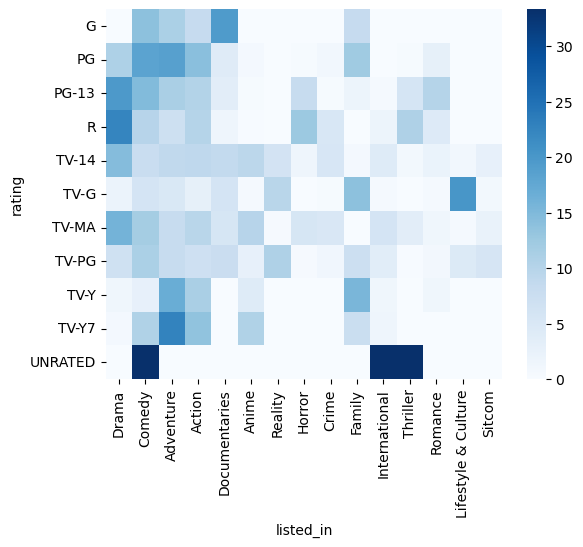

In [59]:
ct = pd.crosstab(df_genre['rating'], df_genre['listed_in'])
top_genres = ct.sum().sort_values(ascending=False).head(15).index
pct = ct.div(ct.sum(1), axis=0) * 100
sns.heatmap(pct[top_genres], cmap='Blues')

# Summary :

Dataset size: 3073 titles, ~even split Movies vs TV Shows (TV slightly higher).

US dominates the catalog; next are Japan/UK/Canada, etc.

Top genres overall: Drama, Comedy, Adventure, Action, Documentaries (from your results).

Over release years, content volume increases a lot in recent years; Documentaries/Drama show strong presence.

Using date_added, Hulu’s monthly additions increase sharply in later years; some seasonal peaks exist (month bar chart).

Data quality notes: lots of missing country, rating/duration mix-up fixed/identified, multi-genre titles cause “explode counts” to be multi-count.

### Limitations :

no exact release date (only year), missing country, multi-label genres.

no data for directors and cast